# Spatial context for compound hot-dry conditions in Germany

## E-OBS 0.1° gridded observational analysis, 1961–2024

This notebook extends the station-composite analysis in `01_compound_hot_dry_analysis.ipynb` to a gridded observational product. It uses E-OBS ensemble-mean daily maximum temperature (`tx`) and daily precipitation (`rr`) on a regular 0.1° grid.

**Purpose.** The station analysis provides a reproducible point/composite reference for two contrasting German climate regions. This notebook provides spatial context: it asks whether warm-season temperature, precipitation and heat-threshold exceedances show geographically structured changes across Germany.

**Scope of this first spatial module.** The notebook performs data checks and descriptive maps. It does not yet apply the full 30-day P10/P20 compound-event detection algorithm to every grid cell. That computational extension should be built only after validating the gridded fields and their relation to the DWD station analysis.

## Data and spatial interpretation

- **Dataset:** E-OBS v31.0e ensemble mean, daily gridded observations derived from the ECA&D station network.
- **Variables:** daily maximum temperature (`tx`, °C) and daily precipitation sum (`rr`, mm).
- **Grid:** regular 0.1° grid; each cell represents an area-scale interpolated estimate, not a point observation.
- **Spatial subset:** 5°E–16°E and 47°N–56°N. This is a geographic bounding box around Germany with a surrounding margin, not an exact political-border mask.
- **Analysis period:** 1961–2024. The 1961–1990 period is retained as the fixed climatic reference baseline, matching the station workflow.

The E-OBS grid should not be expected to exactly reproduce DWD values at individual stations: it is spatially interpolated and therefore smooths local extremes. The intended comparison is of spatial patterns, long-term tendencies and broad regional context rather than exact day-by-day equality.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / 'data').exists()
    else Path.cwd().parent
)
EOBS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'eobs'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'outputs'

ANALYSIS_START = '1961-01-01'
ANALYSIS_END = '2024-12-31'
BASELINE_START = '1961-01-01'
BASELINE_END = '1990-12-31'
RECENT_START = '2005-01-01'
RECENT_END = '2024-12-31'
WARM_MONTHS = [4, 5, 6, 7, 8, 9]

print('Project root:', PROJECT_ROOT)
print('E-OBS subsets:', EOBS_DIR)
print('Outputs:', OUTPUT_DIR)

Project root: /home/abrax/Documents/forest-climate-extremes
E-OBS subsets: /home/abrax/Documents/forest-climate-extremes/data/processed/eobs
Outputs: /home/abrax/Documents/forest-climate-extremes/data/outputs


## Load prepared E-OBS subsets

The raw Europe-wide E-OBS chunks were prepared by `src/prepare_eobs_germany.py`. This notebook reads only the compressed Germany-plus-margin subsets. Loading chunks one by one and concatenating along time avoids requiring a Dask workflow at this exploratory stage.

In [2]:
eobs_paths = sorted(EOBS_DIR.glob('eobs_germany_*_v31.0e.nc'))

if len(eobs_paths) != 5:
    raise FileNotFoundError(
        f'Expected five E-OBS subset files in {EOBS_DIR}, found {len(eobs_paths)}.'
    )

datasets = [xr.open_dataset(path, engine='netcdf4') for path in eobs_paths]
eobs = xr.concat(datasets, dim='time').sortby('time')
eobs = eobs.sel(time=slice(ANALYSIS_START, ANALYSIS_END))

eobs

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 23376, latitude: 90, longitude: 110)
Coordinates:
  * time       (time) datetime64[ns] 187kB 1961-01-01 1961-01-02 ... 2024-12-31
  * latitude   (latitude) float64 720B 47.05 47.15 47.25 ... 55.75 55.85 55.95
  * longitude  (longitude) float64 880B 5.05 5.15 5.25 ... 15.75 15.85 15.95
Data variables:
    tx         (time, latitude, longitude) float32 926MB 6.1 5.59 ... nan nan
    rr         (time, latitude, longitude) float32 926MB 2.0 2.3 2.6 ... nan nan
Attributes:
    title:           E-OBS daily ensemble-mean data subset for Germany
    source_dataset:  E-OBS v31.0e, 0.1 degree regular grid
    source_url:      https://surfobs.climate.copernicus.eu/dataaccess/access_...
    spatial_subset:  longitude 5.0 to 16.0; latitude 47.0 to 56.0
    note:            Geographic bounding box only; not a political-border mas...

## Quality checks

The expected units are °C for maximum temperature and mm for daily precipitation. Missing cells are expected near coastal, border or marine locations because E-OBS is a land-only product and the present subset uses a rectangular geographic domain.

In [3]:
quality = pd.DataFrame(
    {
        'variable': ['tx', 'rr'],
        'description': ['Daily maximum temperature', 'Daily precipitation sum'],
        'units': [eobs['tx'].attrs.get('units'), eobs['rr'].attrs.get('units')],
        'minimum': [float(eobs['tx'].min()), float(eobs['rr'].min())],
        'maximum': [float(eobs['tx'].max()), float(eobs['rr'].max())],
        'missing_pct': [
            float(eobs['tx'].isnull().mean() * 100),
            float(eobs['rr'].isnull().mean() * 100),
        ],
    }
).round(3)

print(
    'Time range:',
    str(eobs.time.min().values)[:10],
    'to',
    str(eobs.time.max().values)[:10],
)
print('Grid:', eobs.sizes['latitude'], 'latitude ×', eobs.sizes['longitude'], 'longitude')
quality

Time range: 1961-01-01 to 2024-12-31
Grid: 90 latitude × 110 longitude


,variable,description,units,minimum,maximum,missing_pct
0,tx,Daily maximum temperature,Celsius,-25.89,47.25,18.0
1,rr,Daily precipitation sum,mm,0.00,242.20,18.0


## Warm-season climatology and recent change

The following maps compare the fixed 1961–1990 baseline with the most recent complete 20-year period available in the validated E-OBS data, 2005–2024. Temperature is represented by the mean of daily warm-season maximum temperatures. Precipitation is represented by the mean April–September accumulated precipitation per year.

These are descriptive changes, not causal attribution estimates.

In [4]:
warm = eobs.where(eobs.time.dt.month.isin(WARM_MONTHS), drop=True)
baseline = warm.sel(time=slice(BASELINE_START, BASELINE_END))
recent = warm.sel(time=slice(RECENT_START, RECENT_END))

baseline_tx = baseline['tx'].mean('time', skipna=True)
recent_tx = recent['tx'].mean('time', skipna=True)
change_tx = recent_tx - baseline_tx

baseline_rr = baseline['rr'].groupby('time.year').sum('time', skipna=True).mean('year')
recent_rr = recent['rr'].groupby('time.year').sum('time', skipna=True).mean('year')
change_rr = recent_rr - baseline_rr

summary_periods = pd.DataFrame(
    {
        'period': ['1961–1990 baseline', '2005–2024 recent'],
        'mean_warm_season_tx_c': [
            float(baseline_tx.mean()),
            float(recent_tx.mean()),
        ],
        'mean_apr_sep_precip_mm_per_year': [
            float(baseline_rr.mean()),
            float(recent_rr.mean()),
        ],
    }
).round(2)
summary_periods

,period,mean_warm_season_tx_c,mean_apr_sep_precip_mm_per_year
0,1961–1990 baseline,18.53,355.14
1,2005–2024 recent,20.43,355.18


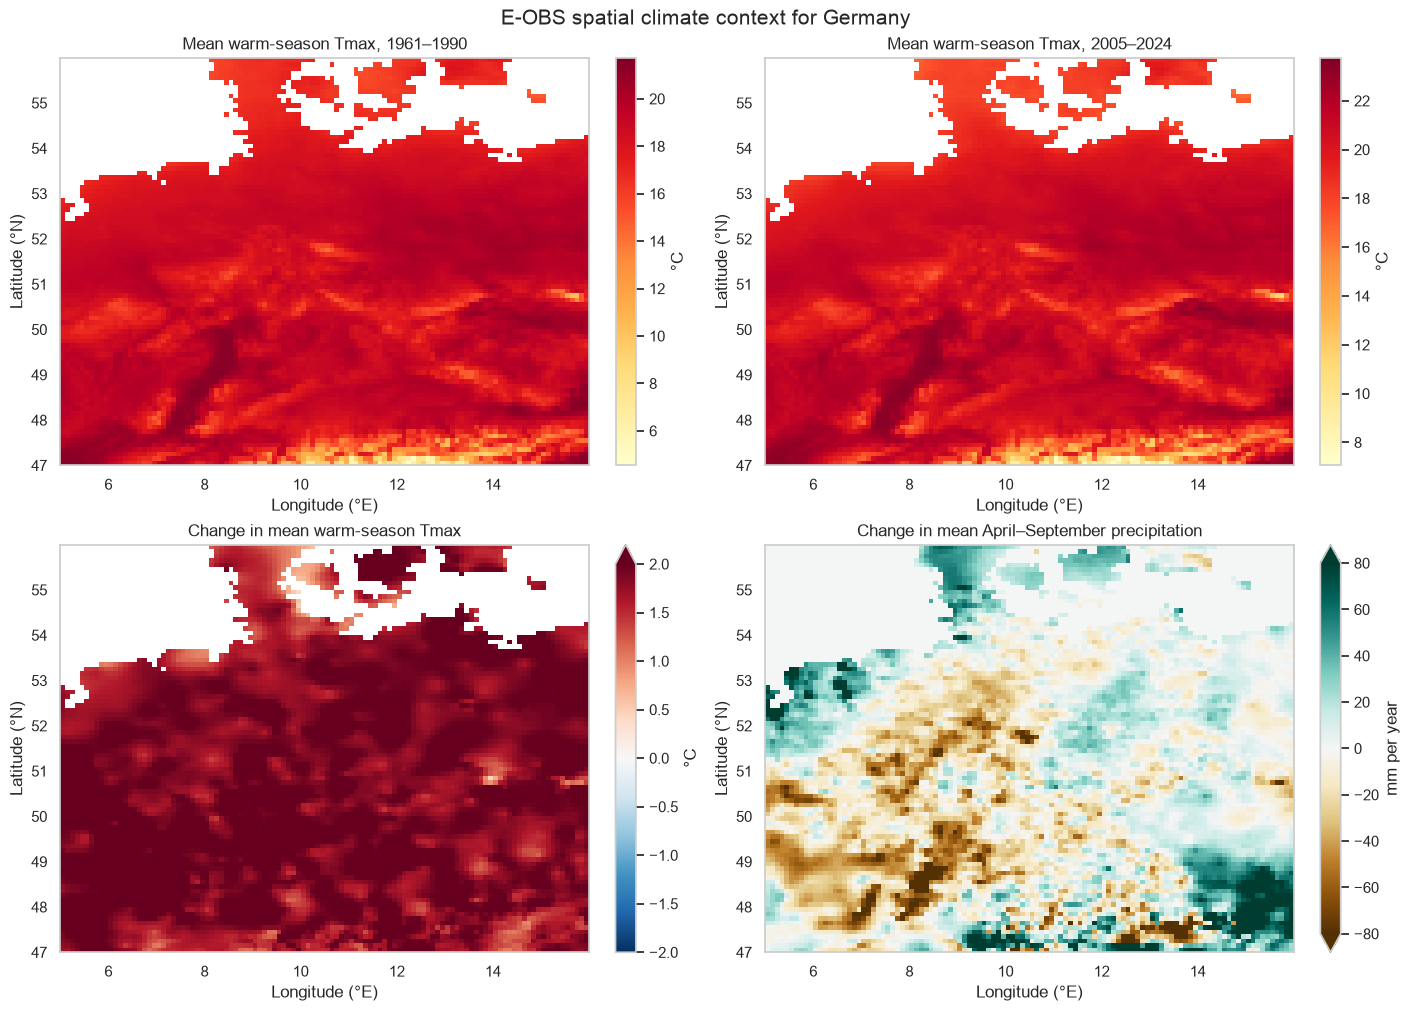

In [5]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    constrained_layout=True,
)

plots = [
    (baseline_tx, 'Mean warm-season Tmax, 1961–1990', 'YlOrRd', '°C', None),
    (recent_tx, 'Mean warm-season Tmax, 2005–2024', 'YlOrRd', '°C', None),
    (change_tx, 'Change in mean warm-season Tmax', 'RdBu_r', '°C', 2.0),
    (change_rr, 'Change in mean April–September precipitation', 'BrBG', 'mm per year', 80.0),
]

for axis, (field, title, cmap, label, limit) in zip(axes.flat, plots):
    kwargs = {'ax': axis, 'cmap': cmap, 'add_colorbar': True}
    if limit is not None:
        kwargs.update({'vmin': -limit, 'vmax': limit})

    image = field.plot(**kwargs)
    image.colorbar.set_label(label)
    axis.set_title(title)
    axis.set_xlabel('Longitude (°E)')
    axis.set_ylabel('Latitude (°N)')

fig.suptitle('E-OBS spatial climate context for Germany', fontsize=15)
plt.show()

## Heat-threshold exceedances

To mirror the temperature component of the station event definition, a local warm-season P90 threshold is calculated independently for each grid cell from the fixed 1961–1990 baseline. This first spatial diagnostic counts the average number of warm-season days per year exceeding that local threshold. It is a heat-only indicator; the precipitation and consecutive-day requirements are added in a later compound-event module.

In [10]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="All-NaN slice encountered",
        category=RuntimeWarning,
    )
    baseline_tx_p90 = baseline["tx"].quantile(
        0.90,
        dim="time",
        skipna=True,
    )

baseline_hot_days = (baseline['tx'] >= baseline_tx_p90)
recent_hot_days = (recent['tx'] >= baseline_tx_p90)

baseline_hot_days_per_year = baseline_hot_days.groupby('time.year').sum('time').mean('year')
recent_hot_days_per_year = recent_hot_days.groupby('time.year').sum('time').mean('year')
change_hot_days_per_year = recent_hot_days_per_year - baseline_hot_days_per_year

pd.DataFrame(
    {
        'period': ['1961–1990 baseline', '2005–2024 recent'],
        'Germany-box mean heat-threshold days per warm season': [
            float(baseline_hot_days_per_year.mean()),
            float(recent_hot_days_per_year.mean()),
        ],
    }
).round(2)

,period,Germany-box mean heat-threshold days per warm season
0,1961–1990 baseline,15.03
1,2005–2024 recent,27.08


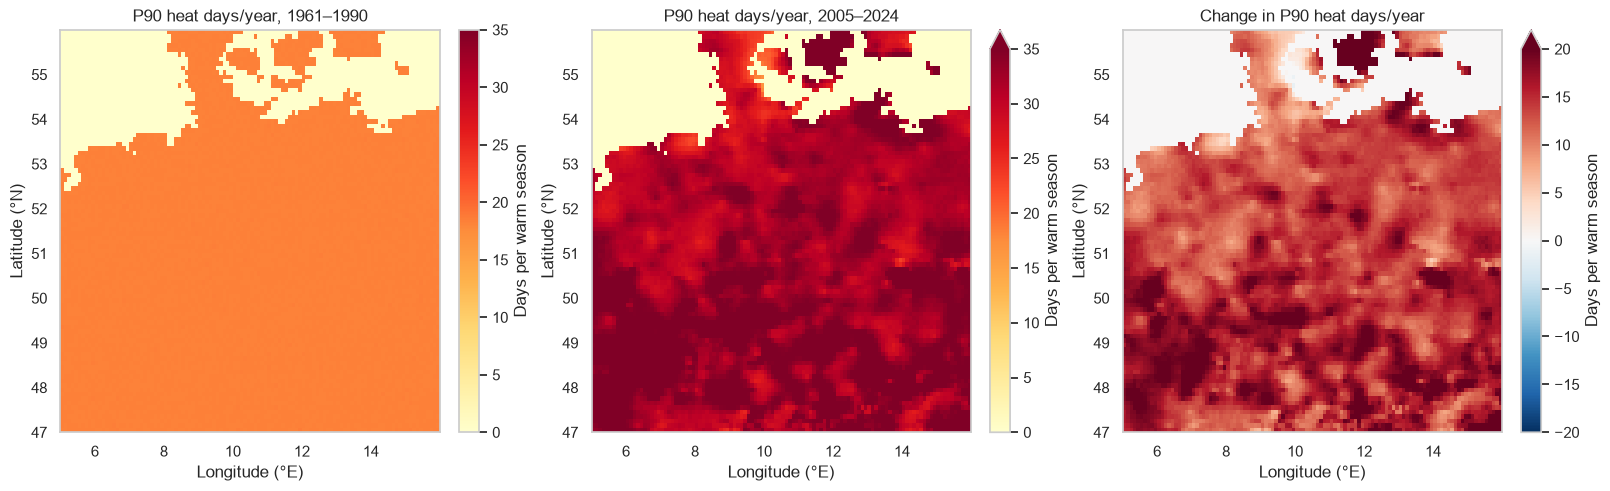

In [11]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 4.8),
    constrained_layout=True,
)

heat_maps = [
    (baseline_hot_days_per_year, 'P90 heat days/year, 1961–1990', 'YlOrRd', 35),
    (recent_hot_days_per_year, 'P90 heat days/year, 2005–2024', 'YlOrRd', 35),
    (change_hot_days_per_year, 'Change in P90 heat days/year', 'RdBu_r', 20),
]

for axis, (field, title, cmap, limit) in zip(axes, heat_maps):
    if 'Change' in title:
        image = field.plot(
            ax=axis,
            cmap=cmap,
            vmin=-limit,
            vmax=limit,
            add_colorbar=True,
        )
    else:
        image = field.plot(
            ax=axis,
            cmap=cmap,
            vmin=0,
            vmax=limit,
            add_colorbar=True,
        )

    image.colorbar.set_label('Days per warm season')
    axis.set_title(title)
    axis.set_xlabel('Longitude (°E)')
    axis.set_ylabel('Latitude (°N)')

plt.show()

## Station-reference locations

The points below are approximate locations for the four DWD stations used in the station-composite workflow. They are included as visual references only. The nearest E-OBS grid cells will later be extracted for a formal station-versus-grid comparison.

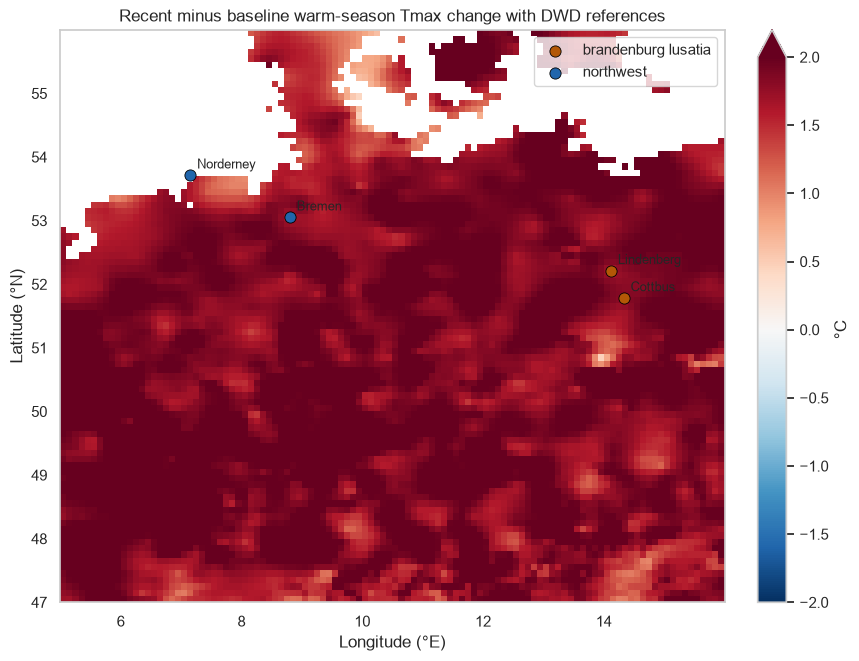

In [8]:
stations = pd.DataFrame(
    [
        {'station': 'Cottbus', 'region': 'brandenburg_lusatia', 'longitude': 14.33, 'latitude': 51.78},
        {'station': 'Lindenberg', 'region': 'brandenburg_lusatia', 'longitude': 14.12, 'latitude': 52.21},
        {'station': 'Bremen', 'region': 'northwest', 'longitude': 8.80, 'latitude': 53.05},
        {'station': 'Norderney', 'region': 'northwest', 'longitude': 7.15, 'latitude': 53.71},
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 6.5), constrained_layout=True)
image = change_tx.plot(ax=ax, cmap='RdBu_r', vmin=-2, vmax=2, add_colorbar=True)
image.colorbar.set_label('°C')

for region, group in stations.groupby('region'):
    color = '#b35806' if region == 'brandenburg_lusatia' else '#2166ac'
    ax.scatter(
        group['longitude'],
        group['latitude'],
        s=65,
        color=color,
        edgecolor='black',
        linewidth=0.6,
        label=region.replace('_', ' '),
        zorder=3,
    )

    for _, station in group.iterrows():
        ax.annotate(
            station['station'],
            (station['longitude'], station['latitude']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
        )

ax.set_title('Recent minus baseline warm-season Tmax change with DWD references')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.legend(frameon=True)
plt.show()

## Interpretation and next steps

This initial spatial module is deliberately descriptive. It establishes that the E-OBS data can be loaded, quality-checked and mapped reproducibly over the Germany bounding box. The station analysis remains the primary event-detection workflow; E-OBS adds area-wide context and enables later mapping of the same compound-event definition.

**Current limitations**

- E-OBS grid cells are interpolated area estimates and do not equal station observations or forest-stand microclimates.
- The domain is a bounding box, not an exact Germany border or forest mask.
- The validated E-OBS data currently end in 2024, while the DWD station workflow includes 2025 and a 2026 monitoring layer.
- Heat-threshold maps use a season-wide local P90 in this first module. The station workflow uses calendar-day-specific thresholds within a ±15-day window; that more exact approach should be carried into the full gridded compound-event calculation.

**Next spatial steps**

1. Extract the nearest E-OBS grid cell for each DWD station and compare warm-season statistics and trends.
2. Implement rolling 30-day precipitation sums for each grid cell.
3. Calculate calendar-day-specific P90 temperature and P10/P20 precipitation thresholds using 1961–1990.
4. Detect at least three consecutive compound hot-dry days at each grid cell.
5. Map compound-event days, trends and uncertainty across Germany, then add forest-cover and soil-moisture context.